In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("Final dataset with mac vari.csv")

In [3]:
df = df.drop(columns=["Newsenti"], errors="ignore")

In [4]:
df.columns

Index(['Date', 'USD_EUR_Ratio', 'Gold_Price', 'Index', 'volatility',
       'Newscore', 'garch_volatility'],
      dtype='object')

In [5]:
df = df.sort_values(by='Date').reset_index(drop=True)

Y = df['volatility']
X = df.drop(columns=['volatility'])

# Add lag features (VERY IMPORTANT for time series)
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()
X = data.drop(columns=["Date",'volatility', "garch_volatility"])
Y = data['volatility']

In [6]:
split = int(0.8 * len(X))

X_train = X.iloc[:split]
X_test = X.iloc[split:]
Y_train = Y.iloc[:split]
Y_test = Y.iloc[split:]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, Y_train)
preds = model.predict(X_test)

In [9]:
rmse = np.sqrt(mean_squared_error(Y_test, preds))
mae = mean_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -1.6604353224069839
RMSE: 0.0076423520238413575
MAE: 0.006858590368421053


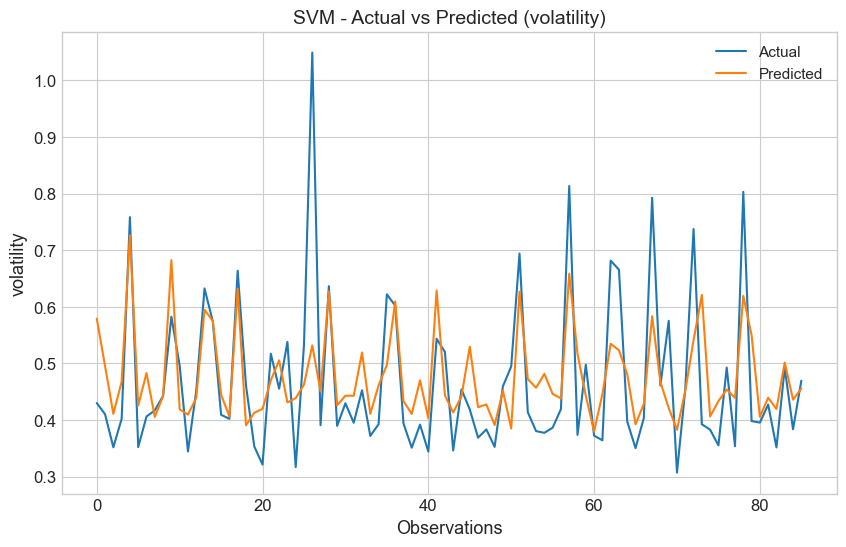

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure()
plt.plot(Y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("SVM - Actual vs Predicted (volatility)")
plt.xlabel("Observations")
plt.ylabel("volatility")
plt.legend()
plt.show()

In [11]:
X = data.drop(columns=["Date",'volatility', "garch_volatility"])
Y = data['garch_volatility']

In [12]:
split = int(0.8 * len(X))

X_train = X.iloc[:split]
X_test = X.iloc[split:]
Y_train = Y.iloc[:split]
Y_test = Y.iloc[split:]

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, Y_train)
preds = model.predict(X_test)

In [15]:
rmse = np.sqrt(mean_squared_error(Y_test, preds))
mae = mean_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.2844956344787265
RMSE: 0.11452558046455688
MAE: 0.08547392473602973


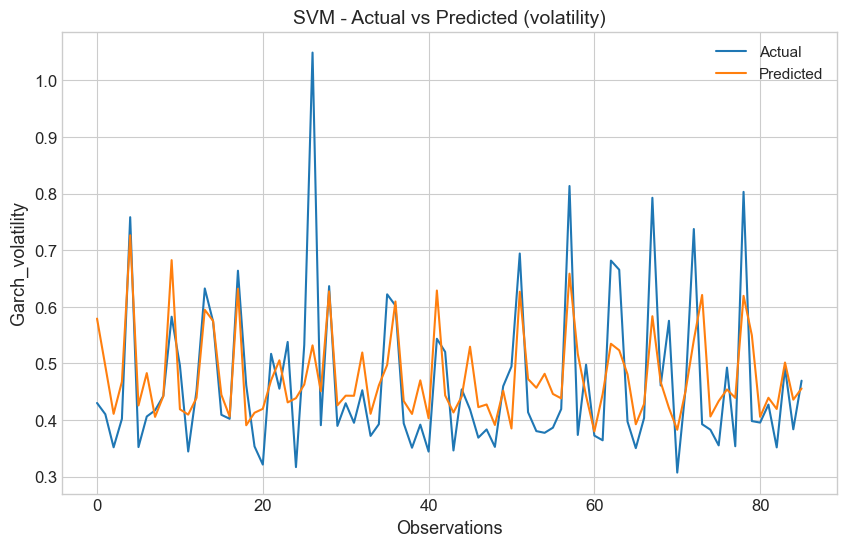

In [24]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({"font.size": 12,"figure.figsize": (10, 6),"axes.labelsize": 13,"axes.titlesize": 14,"legend.fontsize": 11})

plt.figure()
plt.plot(Y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("SVM - Actual vs Predicted (volatility)")
plt.xlabel("Observations")
plt.ylabel("Garch_volatility")
plt.legend()
plt.show()

In [17]:
n = len(X)

splits = [int(0.80 * n),int(0.85 * n),int(0.90 * n),int(0.95 * n)]

In [18]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    # --- Scaling (fit ONLY on train) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- SVM Model ---
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

    model.fit(X_train_scaled, Y_train)

    preds = model.predict(X_test_scaled)

    # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction = np.sign(actual_diff) == np.sign(pred_diff)
    da = np.mean(direction)

    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": da
    })

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {da:.4f}
    """)


    Split 1
    Train Size: 1365
    Test Size: 342
    MSE: 0.0131
    MAE: 0.0855
    R2: 0.2845
    Directional Accuracy: 0.7807
    

    Split 2
    Train Size: 1450
    Test Size: 257
    MSE: 0.0132
    MAE: 0.0869
    R2: 0.2683
    Directional Accuracy: 0.7899
    

    Split 3
    Train Size: 1536
    Test Size: 171
    MSE: 0.0133
    MAE: 0.0841
    R2: 0.2925
    Directional Accuracy: 0.7953
    

    Split 4
    Train Size: 1621
    Test Size: 86
    MSE: 0.0112
    MAE: 0.0777
    R2: 0.3944
    Directional Accuracy: 0.7674
    


In [19]:
results_df = pd.DataFrame(results)
print(results_df)

   Split  Train Size  Test Size       MSE       MAE        R2  \
0      1        1365        342  0.013116  0.085474  0.284496   
1      2        1450        257  0.013196  0.086922  0.268333   
2      3        1536        171  0.013326  0.084136  0.292453   
3      4        1621         86  0.011168  0.077727  0.394429   

   Directional Accuracy  
0              0.780702  
1              0.789883  
2              0.795322  
3              0.767442  


In [20]:
df = df.sort_values(by='Date').reset_index(drop=True)

Y = df['garch_volatility']
X = df.drop(columns=['garch_volatility', 'Date'])

# Add lag features (VERY IMPORTANT for time series)
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()

X = data.drop(columns=['garch_volatility'])
Y = data['garch_volatility']

In [21]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    # --- Scaling (fit ONLY on train) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- SVM Model ---
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

    model.fit(X_train_scaled, Y_train)

    preds = model.predict(X_test_scaled)

    # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction = np.sign(actual_diff) == np.sign(pred_diff)
    da = np.mean(direction)

    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": da
    })

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {da:.4f}
    """)


    Split 1
    Train Size: 1365
    Test Size: 342
    MSE: 0.0116
    MAE: 0.0805
    R2: 0.3670
    Directional Accuracy: 0.7865
    

    Split 2
    Train Size: 1450
    Test Size: 257
    MSE: 0.0116
    MAE: 0.0812
    R2: 0.3587
    Directional Accuracy: 0.7860
    

    Split 3
    Train Size: 1536
    Test Size: 171
    MSE: 0.0115
    MAE: 0.0781
    R2: 0.3881
    Directional Accuracy: 0.8363
    

    Split 4
    Train Size: 1621
    Test Size: 86
    MSE: 0.0101
    MAE: 0.0726
    R2: 0.4510
    Directional Accuracy: 0.7674
    


In [22]:
results_df = pd.DataFrame(results)
print(results_df)

   Split  Train Size  Test Size       MSE       MAE        R2  \
0      1        1365        342  0.011604  0.080504  0.366990   
1      2        1450        257  0.011566  0.081218  0.358728   
2      3        1536        171  0.011524  0.078111  0.388133   
3      4        1621         86  0.010124  0.072584  0.451045   

   Directional Accuracy  
0              0.786550  
1              0.785992  
2              0.836257  
3              0.767442  
